# Signaling Analysis
### Analyzing the performance of the signaling apparatus

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
active_pairs = pd.read_csv("../data/manipulated/active_pairs.csv", parse_dates=True)

train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

validation_residuals = pd.read_csv("../data/manipulated/residuals_val.csv", index_col=0, parse_dates=True)

val_start = validation_residuals.index.min()
val_end = validation_residuals.index.max()

test_residuals = pd.read_csv("../data/manipulated/residuals_test.csv", index_col=0, parse_dates=True)

test_start = test_residuals.index.min()
test_end = test_residuals.index.max()

In [7]:
def compute_match_percentage(df, regime_first=True):
    # if prioritizing regime, exclude rows where gmm_signal == 0
    if regime_first:
        df = df[df["gmm_signal"] != 0]
    # else we prioritize nonzero minhash_signal
    else:
        df = df[df["minhash_signal"] != 0]

    # define match condition
    matches = (
        ((df["gmm_signal"] == 1) & (df["minhash_signal"] > 0)) |
        ((df["gmm_signal"] == -1) & (df["minhash_signal"] < 0))
    )

    return matches.mean()  # proportion

In [ ]:
train_results = []
validation_results = []
test_results = []
full_results = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    
    full = pd.read_csv(filename, index_col=0, parse_dates=True)
    train = full.loc[train_start:train_end]
    val = full.loc[val_start:val_end]
    test = full.loc[test_start:test_end]

    train_pct = compute_match_percentage(train)
    val_pct = compute_match_percentage(val)
    test_pct = compute_match_percentage(test)
    full_pct = compute_match_percentage(full)

    train_results.append(train_pct)
    validation_results.append(val_pct)
    test_results.append(test_pct)
    full_results.append(full_pct)

print("Regime-first match percentages:")
print("Train mean match %:", np.mean(train_results))
print("Validation mean match %:", np.mean(validation_results))
print("Test mean match %:", np.mean(test_results))
print("Full mean match %:", np.mean(full_results))

Train mean match %: 0.7283934071641306
Validation mean match %: 0.43449272276905576
Test mean match %: 0.43831272907252655
Full mean match %: 0.6663467993071385


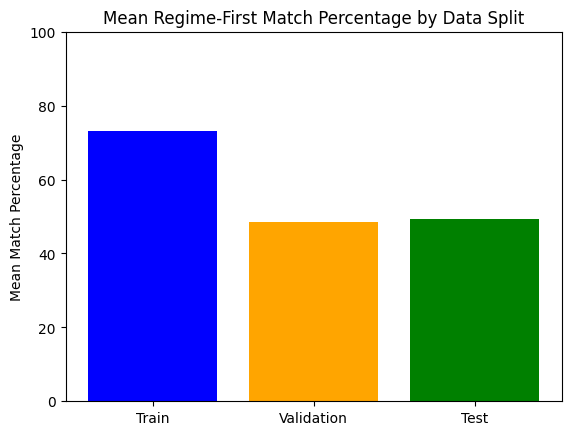

In [10]:
# plot match percentage for each split
splits = ['Train', 'Validation', 'Test']
means = np.array([np.mean(train_results), np.mean(validation_results), np.mean(test_results)])
plt.bar(splits, 100*means, color=['blue', 'orange', 'green'])
plt.ylabel('Mean Match Percentage')
plt.title('Mean Regime-First Match Percentage by Data Split')
plt.ylim(0, 100)
plt.show()

In [9]:
train_results = []
validation_results = []
test_results = []
full_results = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    
    full = pd.read_csv(filename, index_col=0, parse_dates=True)
    train = full.loc[train_start:train_end]
    val = full.loc[val_start:val_end]
    test = full.loc[test_start:test_end]

    train_pct = compute_match_percentage(train, False)
    val_pct = compute_match_percentage(val, False)
    test_pct = compute_match_percentage(test, False)
    full_pct = compute_match_percentage(full, False)

    train_results.append(train_pct)
    validation_results.append(val_pct)
    test_results.append(test_pct)
    full_results.append(full_pct)

print("Minhash-first match percentages:")
print("Train mean match %:", np.mean(train_results))
print("Validation mean match %:", np.mean(validation_results))
print("Test mean match %:", np.mean(test_results))
print("Full mean match %:", np.mean(full_results))

Minhash-first match percentages:
Train mean match %: 0.7303182456774441
Validation mean match %: 0.4853296069908271
Test mean match %: 0.4924071112592754
Full mean match %: 0.6833602669947821


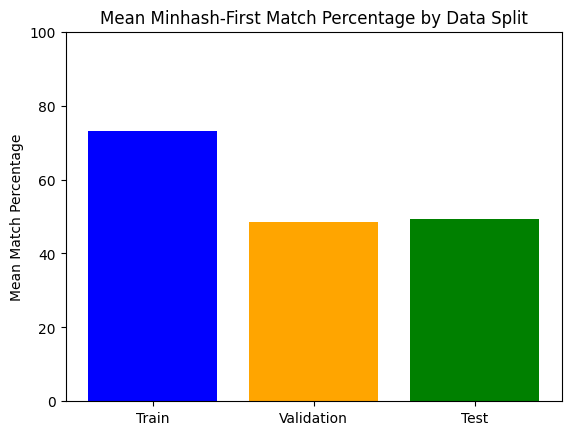

In [11]:
# plot match percentage for each split
splits = ['Train', 'Validation', 'Test']
means = np.array([np.mean(train_results), np.mean(validation_results), np.mean(test_results)])
plt.bar(splits, 100*means, color=['blue', 'orange', 'green'])
plt.ylabel('Mean Match Percentage')
plt.title('Mean Minhash-First Match Percentage by Data Split')
plt.ylim(0, 100)
plt.show()

In [12]:
results = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    
    full = pd.read_csv(filename, index_col=0, parse_dates=True)
    train = full.loc[train_start:train_end]

    results.append({
        "pair": f"{a}_{b}",
        "train_match_pct": compute_match_percentage(train),
        "full_match_pct": compute_match_percentage(full)
    })

results_df = pd.DataFrame(results)
print(results_df)

          pair  train_match_pct  full_match_pct
0      CDW_HAS         0.678571        0.611111
1      CTSH_IT         0.736559        0.665339
2    AMCR_ARES         0.717172        0.630769
3     AMCR_APO         0.699153        0.645695
4      AMCR_IT         0.730994        0.686275
..         ...              ...             ...
109  AMCR_PAYX         0.764706        0.698795
110    APO_BLK         0.719844        0.680251
111    WY_PAYX         0.726708        0.687500
112    CRH_MSI         0.721190        0.679878
113   CBRE_MSI         0.686869        0.625468

[114 rows x 3 columns]


In [13]:
print(results_df["full_match_pct"].min())
print(results_df["full_match_pct"].max())

0.5701357466063348
0.7363636363636363
